In [4]:
import pandas as pd

In [5]:
movies =pd.read_csv(r'C:\Users\HP\Downloads\archive\movie.csv')

In [6]:
len(movies)

27278

In [7]:
movies.shape

(27278, 3)

In [8]:
movies.head(1)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


In [9]:
ratings=pd.read_csv(r'C:\Users\HP\Downloads\archive\rating.csv')

In [10]:
ratings.shape

(1048575, 4)

In [11]:
tags=pd.read_csv(r'C:\Users\HP\Downloads\archive\tag.csv')

In [12]:
tags

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,24-04-2009 18:19
1,65,208,dark hero,10-05-2013 01:41
2,65,353,dark hero,10-05-2013 01:41
3,65,521,noir thriller,10-05-2013 01:39
4,65,592,dark hero,10-05-2013 01:41
...,...,...,...,...
465559,138446,55999,dragged,23-01-2013 23:29
465560,138446,55999,Jason Bateman,23-01-2013 23:29
465561,138446,55999,quirky,23-01-2013 23:29
465562,138446,55999,sad,23-01-2013 23:29


In [13]:
tags.head(1)

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,24-04-2009 18:19


In [14]:
tags.shape

(465564, 4)

In [15]:
print(movies.shape)
print(ratings.shape)
print(tags.shape)

(27278, 3)
(1048575, 4)
(465564, 4)


In [16]:
del ratings['timestamp'] #this is used to delete the column or thr rows from the data set
del tags['timestamp']

In [17]:
print(movies.shape)
print(ratings.shape)
print(tags.shape)

(27278, 3)
(1048575, 3)
(465564, 3)


In [18]:
# have to work till 44 from the kaggle  

In [19]:
# https://www.kaggle.com/code/harunshimanto/pandas-with-data-science-ai

#Data Structures:
# Series¶

In [20]:
row_0 = tags.iloc[0]
type(row_0)

pandas.core.series.Series

In [21]:
print(row_0)

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object


In [22]:
row_0.index

Index(['userId', 'movieId', 'tag'], dtype='object')

In [23]:
row_0['userId']

np.int64(18)

In [24]:
'rating' in row_0

False

In [25]:
row_0.name

0

In [26]:
row_0 = row_0.rename('firstRow')
row_0.name

'firstRow'

#DataFrames¶

In [28]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [29]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [30]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [31]:
tags.iloc[ [0,11,500] ]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue


#Descriptive Statistics¶

In [33]:
ratings['rating'].describe()

count    1.048575e+06
mean     3.529272e+00
std      1.051919e+00
min      5.000000e-01
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [34]:
ratings.describe()

,userId,movieId,rating
count,1.048575e+06,1.048575e+06,1.048575e+06
mean,3.527086e+03,8.648988e+03,3.529272e+00
std,2.018424e+03,1.910014e+04,1.051919e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,1.813000e+03,9.030000e+02,3.000000e+00
50%,3.540000e+03,2.143000e+03,4.000000e+00
75%,5.233000e+03,4.641000e+03,4.000000e+00
max,7.120000e+03,1.306420e+05,5.000000e+00


In [35]:
ratings['rating'].mean()

np.float64(3.5292716305462175)

In [36]:
ratings.mean()

userId     3527.086123
movieId    8648.988281
rating        3.529272
dtype: float64

In [37]:
ratings['rating'].min()

0.5

In [38]:
ratings['rating'].max()

5.0

In [39]:
ratings['rating'].std()

1.0519187535891295

In [40]:
ratings['rating'].mode()

0    4.0
Name: rating, dtype: float64

In [41]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.002837,0.017105
movieId,-0.002837,1.000000,0.002550
rating,0.017105,0.002550,1.000000


In [42]:
filter1 = ratings['rating'] > 10
print(filter1)
filter1.any()

0          False
1          False
2          False
3          False
4          False
           ...  
1048570    False
1048571    False
1048572    False
1048573    False
1048574    False
Name: rating, Length: 1048575, dtype: bool


np.False_

#Data Cleaning: Handling Missing Data

In [43]:
movies.shape

(27278, 3)

In [44]:
movies.isnull().any().any()

np.False_

In [45]:
ratings.shape

(1048575, 3)

In [46]:
ratings.isnull().any().any()

np.False_

In [47]:
tags.shape

(465564, 3)

In [48]:
tags.isnull().any().any()

np.True_

In [52]:
tags=tags.dropna()   #this will reduced the number of lines which has null values

In [55]:
tags.isnull().any().any()  #this will check the dataset to see if it has null values or not

np.False_

In [56]:
tags.shape

(465548, 3)

#Data Visualization¶

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

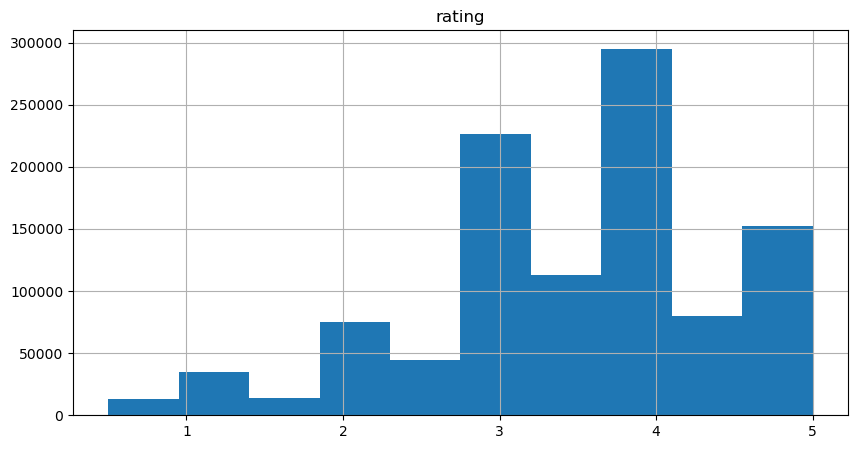

In [57]:
%matplotlib inline

ratings.hist(column='rating', figsize=(10,5))

<Axes: >

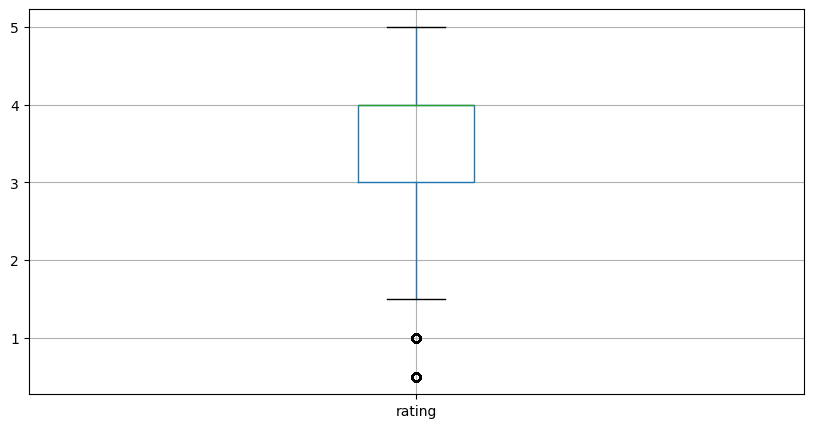

In [58]:
ratings.boxplot(column='rating', figsize=(10,5))

# Slicing Out Columns

In [59]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: object

In [60]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [61]:
ratings[-10:]

,userId,movieId,rating
1048565,7120,141,5.0
1048566,7120,151,5.0
1048567,7120,153,0.5
1048568,7120,161,4.0
1048569,7120,163,4.5
1048570,7120,168,5.0
1048571,7120,253,4.0
1048572,7120,260,5.0
1048573,7120,261,4.0
1048574,7120,266,3.5


In [62]:
tag_counts = tags['tag'].value_counts()
tag_counts[-10:]

tag
missing child                    1
Ron Moore                        1
Citizen Kane                     1
mullet                           1
biker gang                       1
Paul Adelstein                   1
the wig                          1
killer fish                      1
genetically modified monsters    1
topless scene                    1
Name: count, dtype: int64

<Axes: xlabel='tag'>

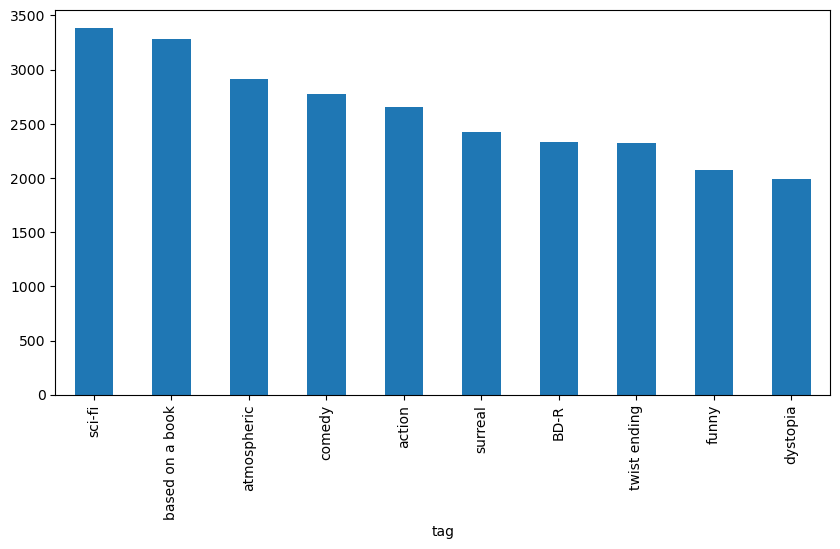

In [64]:
tag_counts[:10].plot(kind='bar', figsize=(10,5))